# 🍎 Classificação da Qualidade das Frutas

## Introdução

Este conjunto de df_quality reúne informações sobre **características físicas e químicas de frutas**, incluindo tamanho, peso, doçura, crocância, acidez e estágio de maturação.  
Ele é adequado para análises estatísticas e tarefas de aprendizado de máquina voltadas a prever a **qualidade final da fruta**.

Segundo a FAO (Organização das Nações Unidas para a Alimentação e Agricultura):

> Estima-se que cerca de **45% das frutas produzidas no mundo são desperdiçadas** devido a problemas de qualidade e conservação.

## Objetivo do Projeto

Desenvolver e avaliar modelos de **classificação binária** para estimar se uma fruta é de **boa** ou **má qualidade** com base em seus atributos.  

- **Variável-alvo** sugerida: `Quality`  

Classes: `BOA QUALIDADE vs MÁ QUALIDADE`  

Sugestão de codificação: `1 = BOA QUALIDADE, 0 = MÁ QUALIDADE`

---

### 📖 Dicionário de Dados

Este conjunto de df_quality contém as seguintes colunas:

1. **Size**: Tamanho da fruta.  
2. **Weight**: Peso da fruta.  
3. **Sweetness**: Nível de doçura.  
4. **Juiciness**: Grau de crocância/suculência.  
5. **Ripeness**: Estágio de maturação da fruta.  
6. **Acidity**: Nível de acidez.  
7. **Quality**: Variável alvo (boa ou ruim).  

## Importação das Bibliotecas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (balanced_accuracy_score,
                             confusion_matrix)
# Others
#==========================================================
from collections import Counter
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, accuracy_score

Carregando o DataFrame

In [ ]:
df_quality= pd.read_csv('apple_quality.csv')
df_quality.head()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good


Visualizando as Dimensões do DataFrame

- 4001 Linhas
- 9 Colunas

In [ ]:
df_quality.shape

(4001, 9)

Dropando a Coluna `A_id`

In [ ]:
df_quality=df_quality.drop(columns ="A_id")
df_quality.head(2)

,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.32984,-0.491590483,good
1,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.86753,-0.722809367,good


## Estrutura do DataFrame

A base de dados utilizada contém **4.000 amostras** e **8 variáveis**, todas completas, ou seja, **sem valores ausentes**.

### ✅ Informações gerais:
- **Formato:** `pandas.DataFrame`
- **Número de entradas:** 4.000
- **Número de colunas:** 8
- **Tipos de dados:**
  - `float64`: 7 colunas (variáveis numéricas contínuas)
  - `object`: 1 coluna (variável alvo categórica)

### 📌 Variáveis do conjunto de dados

As variáveis preditoras descrevem propriedades físicas, químicas e sensoriais das frutas:

- **Size** → Tamanho da fruta.  
- **Weight** → Peso da fruta.  
- **Sweetness** → Nível de doçura.  
- **Crunchiness** → Grau de crocância.  
- **Juiciness** → Grau de suculência.  
- **Ripeness** → Estágio de maturação.  
- **Acidity** → Nível de acidez.  

A variável **`Quality`** é a **variável-alvo**, armazenada como categórica (`object`), que indica se a fruta é de **boa qualidade (1)** ou **má qualidade (0)**.

### 🧪 Considerações
Esse conjunto de dados é balanceado em termos de variáveis numéricas contínuas e categóricas, com atributos diretamente relacionados à percepção de qualidade da fruta.  
A variável-alvo (`Quality`) precisará ser transformada em formato **numérico** para uso em modelos supervisionados.  

Na próxima etapa, investigaremos **estatísticas descritivas** e possíveis correlações entre os atributos para identificar padrões relevantes.


In [ ]:
df_quality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Size         4000 non-null   float64
 1   Weight       4000 non-null   float64
 2   Sweetness    4000 non-null   float64
 3   Crunchiness  4000 non-null   float64
 4   Juiciness    4000 non-null   float64
 5   Ripeness     4000 non-null   float64
 6   Acidity      4001 non-null   object 
 7   Quality      4000 non-null   object 
dtypes: float64(6), object(2)
memory usage: 250.2+ KB


Distribuição de Classes
- `Good`: 2004 Dados
- `Bad`: 2996 Dados

In [ ]:
df_quality["Quality"].value_counts()

,count
Quality,
good,2004
bad,1996


## 🔍 Verificação de Valores Ausentes

Antes de avançar para análises mais profundas e a modelagem, é fundamental verificar se o conjunto de dados possui **valores ausentes**, pois isso pode impactar diretamente a performance dos algoritmos de machine learning.

A inspeção foi realizada com o método `isnull().sum()`, que retorna a quantidade de valores nulos por coluna.

### ✅ Resultado

Foram identificados alguns valores ausentes em quase todas as variáveis do dataset:

| Coluna       | Valores Ausentes |
|--------------|------------------|
| Size         | 1                |
| Weight       | 1                |
| Sweetness    | 1                |
| Crunchiness  | 1                |
| Juiciness    | 1                |
| Ripeness     | 1                |
| Acidity      | 0                |
| Quality      | 1                |

### 🧪 Considerações

- Apenas a variável **`Acidity`** não possui valores nulos.  
- As demais colunas apresentam **1 valor ausente cada**, o que corresponde a menos de **0,03% do total de 4.000 amostras**.  
- Esse baixo índice de ausência permite que os dados sejam tratados facilmente, seja por **remoção direta das linhas** com nulos ou por técnicas simples de **imputação**.  

👉 Conclusão: a base é considerada **limpa e consistente**, necessitando apenas de um tratamento pontual dos valores ausentes antes de seguir para as próximas etapas.


In [ ]:
df_quality.isnull().sum()

,0
Size,1
Weight,1
Sweetness,1
Crunchiness,1
Juiciness,1
Ripeness,1
Acidity,0
Quality,1


Dropando os Valores Vazios

- Valores Ausentes: 0

In [ ]:
df_quality = df_quality.dropna()
df_quality.isnull().sum()

,0
Size,0
Weight,0
Sweetness,0
Crunchiness,0
Juiciness,0
Ripeness,0
Acidity,0
Quality,0


Visualizando Novamente a Quantidade de Valores NaNs

In [ ]:
df_quality.sum().isnull()

<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Size         4000 non-null   float64
 1   Weight       4000 non-null   float64
 2   Sweetness    4000 non-null   float64
 3   Crunchiness  4000 non-null   float64
 4   Juiciness    4000 non-null   float64
 5   Ripeness     4000 non-null   float64
 6   Acidity      4000 non-null   object 
 7   Quality      4000 non-null   object 
dtypes: float64(6), object(2)
memory usage: 281.2+ KB


Tratamento de Dados
1. Transformando o valor da coluna `Acidity` de `object` em `float`

In [ ]:
df_quality["Acidity"] = df_quality["Acidity"].astype(float)
df_quality.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Size         4000 non-null   float64
 1   Weight       4000 non-null   float64
 2   Sweetness    4000 non-null   float64
 3   Crunchiness  4000 non-null   float64
 4   Juiciness    4000 non-null   float64
 5   Ripeness     4000 non-null   float64
 6   Acidity      4000 non-null   float64
 7   Quality      4000 non-null   object 
dtypes: float64(7), object(1)
memory usage: 281.2+ KB


## 📊 Estatísticas Descritivas

Para entender melhor a distribuição das variáveis numéricas, utilizamos o método `describe()`. A análise trouxe alguns pontos importantes:

### 🔎 Insights Relevantes

- **Escalas amplas**: Variáveis como `Size`, `Weight` e `Sweetness` apresentam valores que vão de negativos até acima de 6, sugerindo que os dados foram **padronizados** previamente (média próxima de zero).  
  ➝ Isso facilita comparações, mas exige atenção ao interpretar os resultados.

- **Alta variabilidade**:  
  - `Acidity` apresenta o maior desvio padrão (≈ 2.1), indicando que o **nível de acidez varia bastante** entre as frutas.  
  - `Crunchiness`, `Juiciness` e `Ripeness` também têm grande amplitude, refletindo **diferentes estágios de maturação e qualidade sensorial**.

- **Distribuições centradas próximas de zero**: A maioria das variáveis possui média negativa ou levemente positiva, reforçando o **uso prévio de padronização**. Isso sugere que a base já está parcialmente preparada para algoritmos de machine learning.

- **Outliers potenciais**: Os valores mínimos (< -6) e máximos (> 7) em quase todas as variáveis indicam a presença de **casos extremos**, que podem representar frutas atípicas ou erros de medição.  
  ➝ Será necessário verificar se esses outliers devem ser tratados ou mantidos como exemplos reais.

### 🧪 Considerações

Essa análise mostra que o dataset é **rico em variabilidade**, com atributos que capturam bem a diversidade entre as frutas.  
Porém, devido à amplitude dos valores e possíveis outliers, será essencial aplicar **técnicas de normalização, padronização e detecção de valores extremos** antes do treinamento dos modelos preditivos.


In [ ]:
df_quality.describe()

,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,-0.503015,-0.989547,-0.470479,0.985478,0.512118,0.498277,0.076877
std,1.928059,1.602507,1.943441,1.402757,1.930286,1.874427,2.110270
min,-7.151703,-7.149848,-6.894485,-6.055058,-5.961897,-5.864599,-7.010538
25%,-1.816765,-2.011770,-1.738425,0.062764,-0.801286,-0.771677,-1.377424
50%,-0.513703,-0.984736,-0.504758,0.998249,0.534219,0.503445,0.022609
75%,0.805526,0.030976,0.801922,1.894234,1.835976,1.766212,1.510493
max,6.406367,5.790714,6.374916,7.619852,7.364403,7.237837,7.404736


# 📊 Análise dos Boxplots das Variáveis em Relação à Qualidade da Fruta

## 🔎 Interpretação Geral
Os **boxplots** exibem como as variáveis numéricas se distribuem em relação à variável-alvo **Quality** (classes: *good* e *bad*).  
Esse tipo de análise permite identificar **diferenças estatísticas** e **tendências** entre frutas boas e ruins, além de verificar a presença de **outliers**.

---

## 🍎 Insights por Variável

- **Size (Tamanho):**
  - Frutas boas (*good*) tendem a apresentar tamanhos ligeiramente maiores e mais concentrados.
  - Em *bad*, observa-se maior presença de outliers negativos (frutas muito pequenas).

- **Weight (Peso):**
  - Semelhante ao tamanho, frutas *good* mostram pesos um pouco superiores.
  - Há maior dispersão nos exemplos de *bad*, indicando inconsistência no peso de frutas de baixa qualidade.

- **Sweetness (Doçura):**
  - A mediana de *good* é mais elevada, sugerindo que frutas boas são geralmente mais doces.
  - Frutas ruins apresentam distribuição deslocada para valores mais baixos de doçura.

- **Crunchiness (Crocância):**
  - A diferença entre as classes não é tão acentuada, mas *good* mantém mediana levemente maior.
  - Alguns outliers em ambas as classes sugerem variabilidade no fator crocância.

- **Juiciness (Sucosidade):**
  - A sucosidade é mais alta em *good*, com valores de dispersão menos extremos.
  - Frutas ruins tendem a apresentar menor sucosidade.

- **Ripeness (Maturação):**
  - Frutas *good* concentram-se em estágios de maturação equilibrados.
  - Frutas *bad* têm valores mais altos, sugerindo **excesso de maturação** como fator de má qualidade.

- **Acidity (Acidez):**
  - Diferença menos evidente entre as classes.
  - A acidez parece não ser um fator determinante tão forte para separar frutas boas e ruins, embora a mediana de *bad* seja ligeiramente mais elevada.

---

## ✅ Conclusões
- Variáveis como **Sweetness**, **Juiciness** e **Ripeness** apresentam **maior poder discriminativo** entre frutas boas e ruins.  
- **Size** e **Weight** também contribuem, mas com sobreposição significativa entre as classes.  
- **Acidity** e **Crunchiness** possuem impacto mais limitado, mas ainda oferecem informação complementar.  

Esses resultados reforçam a importância de explorar **seleção de atributos** e técnicas de **feature importance** nos modelos preditivos, já que nem todas as variáveis têm a mesma relevância na classificação da qualidade da fruta.


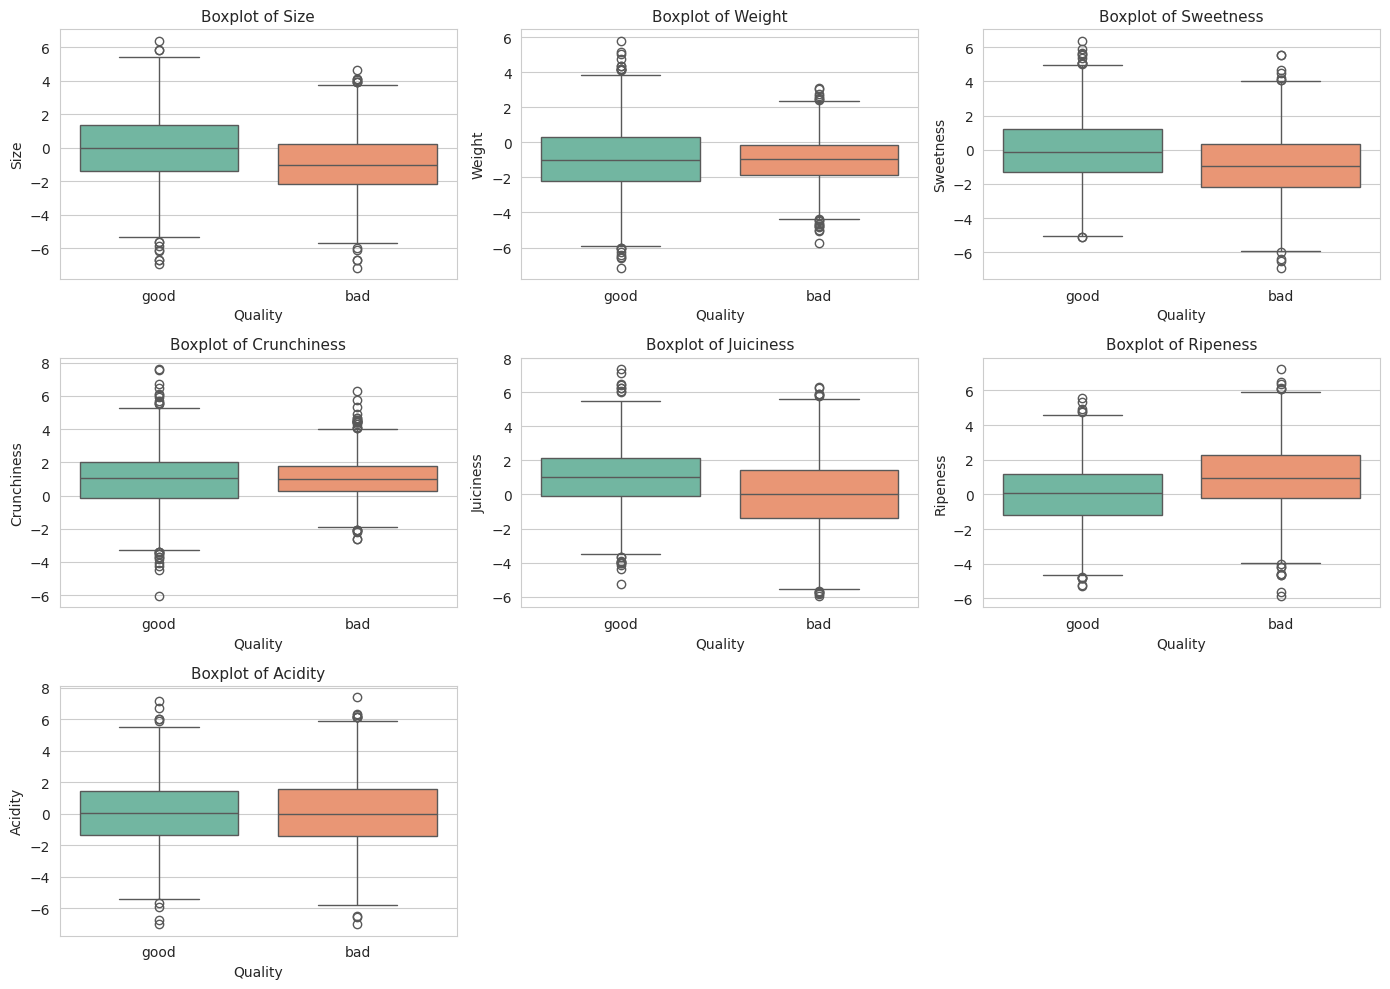

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo
sns.set_style("whitegrid")

# Seleciona apenas as variáveis explicativas (sem a variável alvo 'Quality')
features = df_quality.columns[:-1]

# Define grid de subplots (3 colunas, ajusta linhas automaticamente)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14, 10))
axes = axes.flatten()  # transforma em array 1D para iterar mais fácil

# Loop para plotar cada variável
for i, col in enumerate(features):
    sns.boxplot(x="Quality", y=col, data=df_quality, ax=axes[i], palette="Set2")
    axes[i].set_title(f"Boxplot of {col}", fontsize=11)
    axes[i].set_xlabel("Quality")
    axes[i].set_ylabel(col)

# Remove eixos extras caso não sejam usados
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# Distribuição das Classes de Qualidade

## 📊 Visão Geral
O gráfico acima mostra a **distribuição das classes de qualidade das maçãs** no dataset.  
As classes são balanceadas entre:

- **good (boa qualidade):** aproximadamente **2004 amostras**  
- **bad (má qualidade):** aproximadamente **1994 amostras**

## ✅ Insights

- O **balanceamento entre classes** é praticamente perfeito, o que é um ponto positivo para o treinamento de modelos de Machine Learning.
- Diferente de problemas de classificação com forte desbalanceamento (como inadimplência, fraudes, etc.), aqui **não há necessidade de técnicas de reamostragem** como SMOTE, oversampling ou undersampling.
- Com essa distribuição, a **métrica de avaliação acurácia** já é uma boa escolha, pois ambas as classes estão representadas de forma proporcional.
- Além da acurácia, métricas como **precisão, recall e F1-score** podem ser utilizadas para avaliar se o modelo não favorece nenhuma das classes.

## 🔍 Conclusão
O dataset de qualidade das maçãs apresenta **equilíbrio entre as classes**, o que facilita a modelagem e garante que o desempenho dos algoritmos reflita de forma justa a capacidade de classificar tanto frutas de boa quanto de má qualidade.


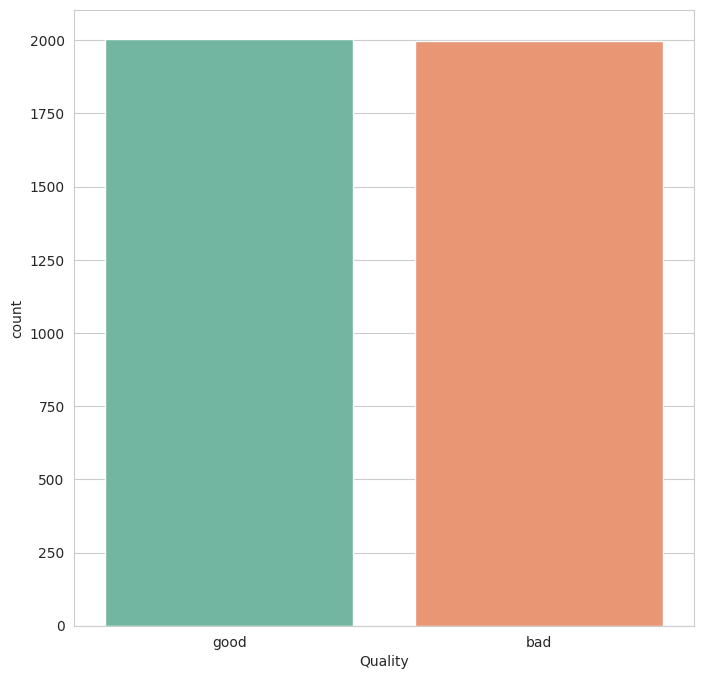

Quality
good    2004
bad     1996
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(8,8))
sns.countplot(x="Quality", data=df_quality, palette ='Set2')
plt.show()
print(df_quality["Quality"].value_counts())

# Análise Exploratória – Pairplot das Variáveis

## 📌 Objetivo
O gráfico *pairplot* foi utilizado para visualizar a distribuição individual das variáveis numéricas e também a relação entre elas, diferenciando as classes de **qualidade da fruta**:  
- **good** (boa qualidade)  
- **bad** (má qualidade)  

Essa abordagem permite observar tanto **padrões de distribuição univariada** (diagonais) quanto **relações bivariadas** (fora da diagonal).

---

## 🔍 Observações Relevantes

### 1. Distribuições Individuais
- As variáveis apresentam distribuições **aproximadamente centradas em zero** devido à padronização.  
- Algumas características, como **Sweetness (doçura)** e **Ripeness (maturação)**, exibem diferenças sutis na densidade entre as classes `good` e `bad`.

### 2. Relações Entre Variáveis
- **Size e Weight** mostram correlação visualmente perceptível: frutas maiores tendem a ser mais pesadas.  
- Outras combinações, como **Sweetness x Juiciness**, não apresentam uma separação clara entre `good` e `bad`, sugerindo que isoladamente não são bons discriminadores.  

### 3. Separação das Classes
- As classes `good` e `bad` estão **fortemente sobrepostas** em quase todas as variáveis quando analisadas isoladamente.  
- Isso reforça a necessidade de **modelos de machine learning multivariados**, capazes de capturar interações complexas entre os atributos.  

---

## 🎯 Conclusão
- O pairplot mostra que **nenhuma variável sozinha é suficiente para separar as classes de qualidade da fruta**.  
- Contudo, a combinação entre múltiplos atributos (ex.: tamanho, peso, acidez e maturação) pode fornecer sinais relevantes para distinguir `good` de `bad`.  
- Essa análise justifica a escolha de **modelos supervisionados robustos** como *Random Forest*, *Extra Trees* ou até mesmo redes neurais, que lidam bem com interações entre variáveis.



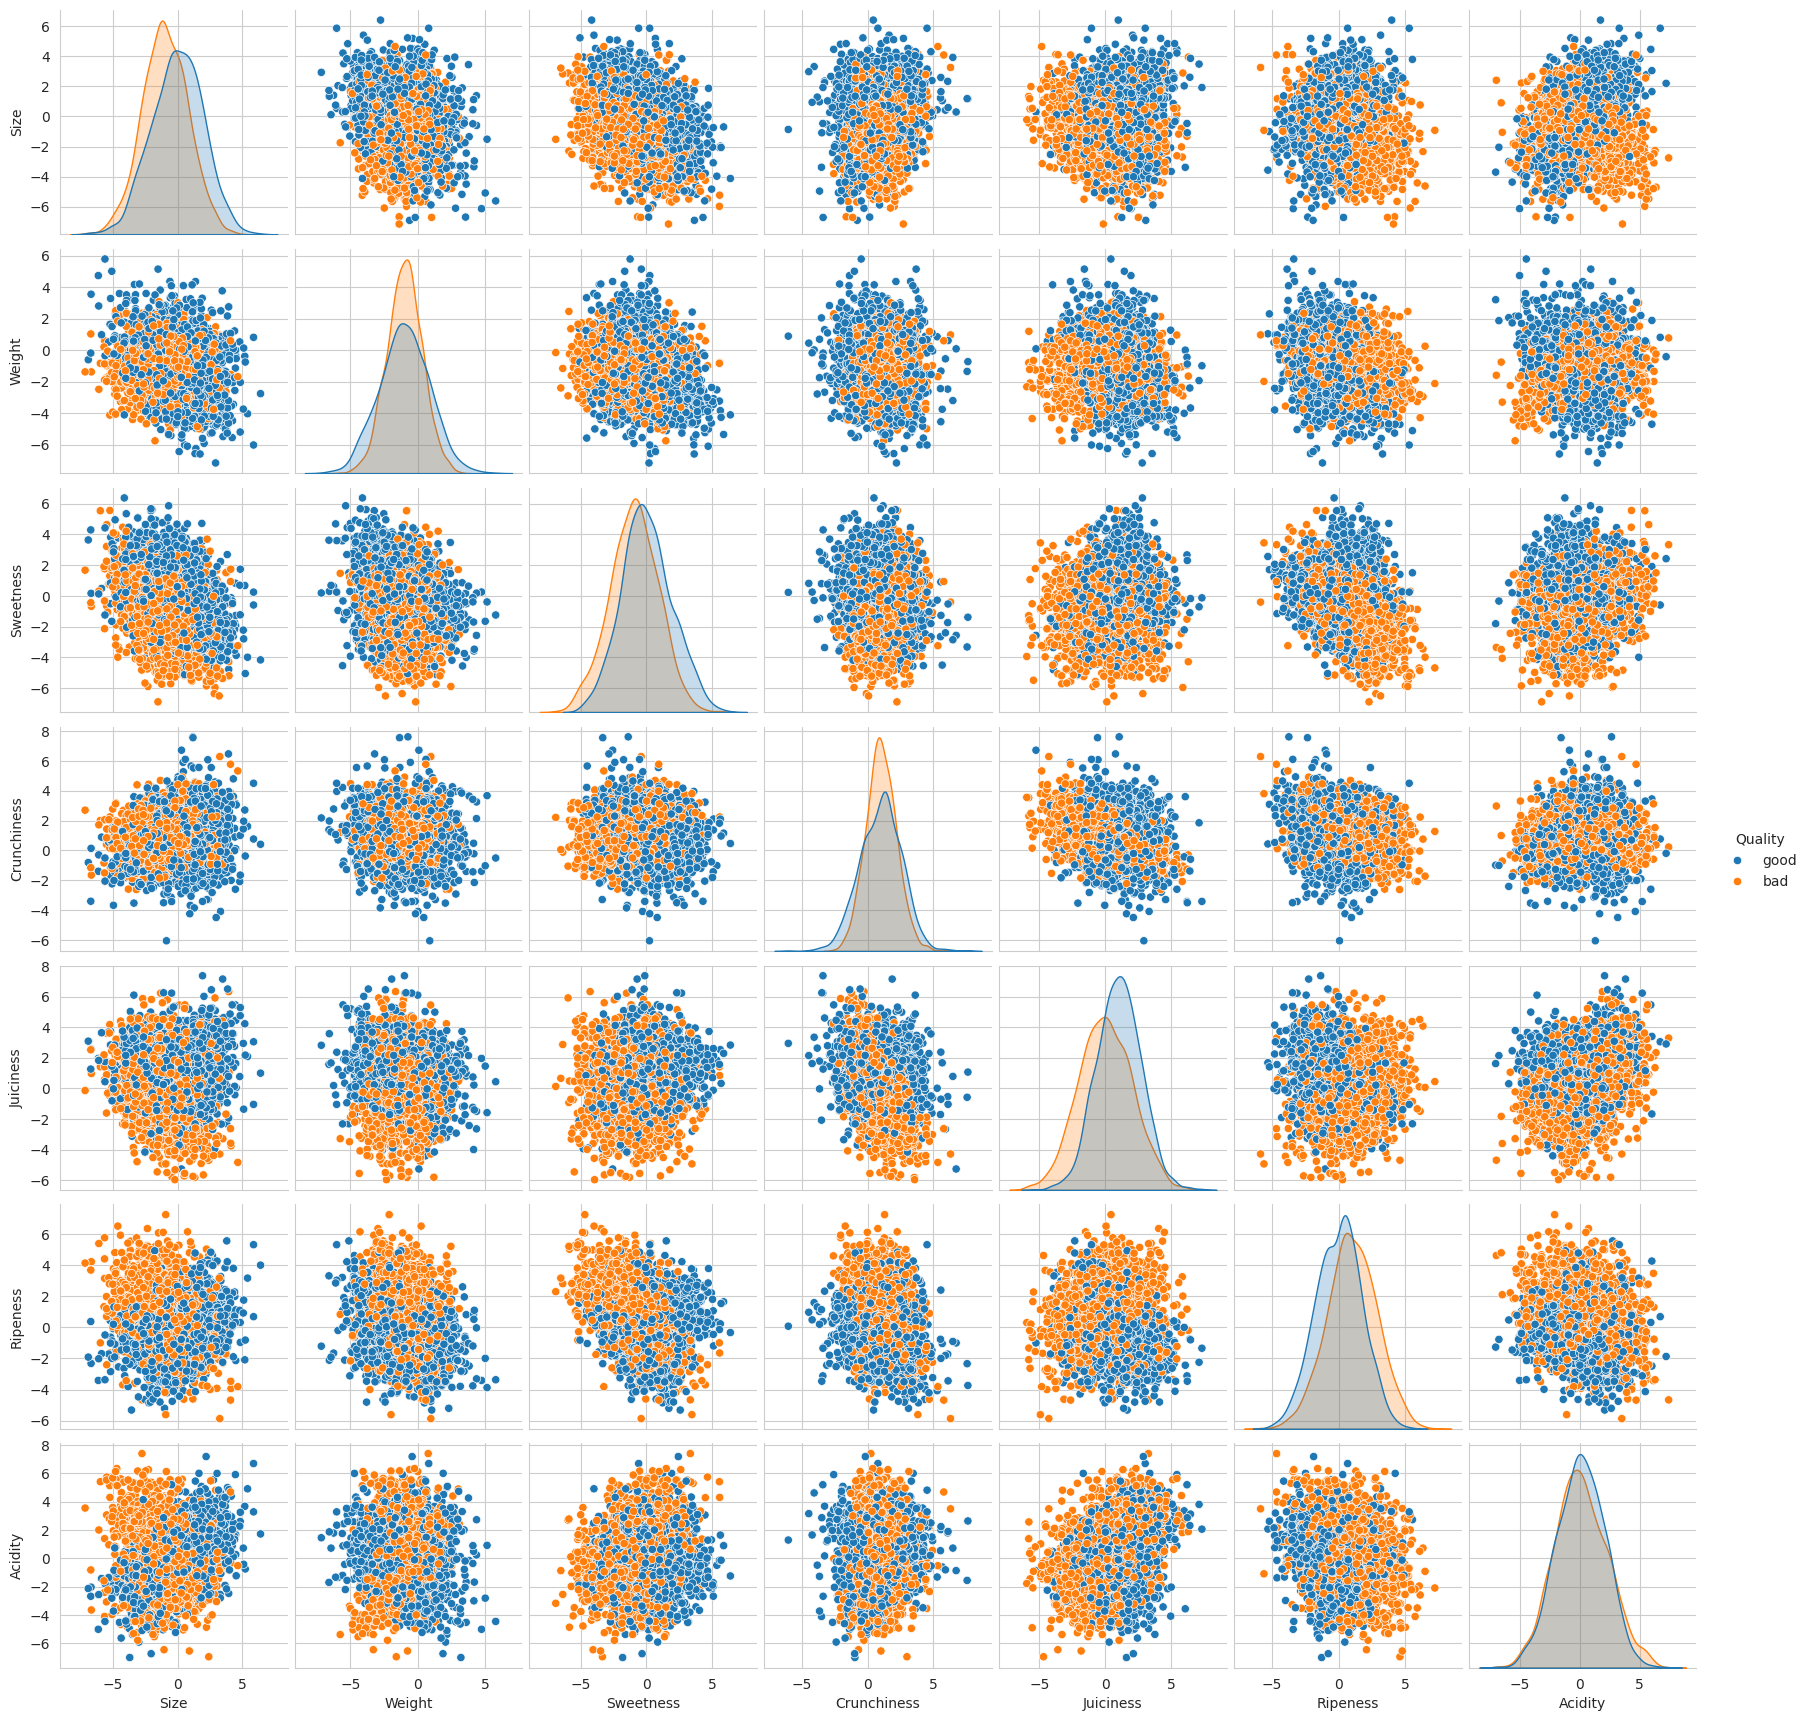

In [ ]:
sns.pairplot(df_quality, hue="Quality")
plt.show()

# 🔍 Análise de Correlação das Variáveis

## 📊 Objetivo
O gráfico acima apresenta a **matriz de correlação de Pearson** entre as variáveis numéricas do dataset de qualidade de frutas.  
O objetivo é identificar relações lineares fortes ou fracas que possam indicar redundância ou complementaridade entre atributos.

---

## ✅ Principais Observações

- **Correlação negativa moderada entre `Size` e `Sweetness` (-0.32):**
  - Frutas maiores tendem a ser menos doces.
  - Pode indicar que o aumento do tamanho compromete a percepção de doçura.

- **Correlação positiva entre `Juiciness` e `Acidity` (0.25):**
  - Frutas mais suculentas apresentam também tendência a serem mais ácidas.
  - Essa relação pode impactar diretamente na avaliação da qualidade.

- **Correlação negativa entre `Ripeness` e `Sweetness` (-0.27):**
  - À medida que a maturação avança, a doçura tende a diminuir.
  - Esse padrão pode ser um dos diferenciais entre as classes *good* e *bad*.

- **Baixa correlação entre a maioria das variáveis:**
  - A matriz mostra valores próximos de zero em grande parte das combinações.
  - Isso sugere que cada atributo traz **informação única**, aumentando a utilidade para o modelo preditivo.

---

## 🎯 Implicações para o Modelo
- Não há indícios fortes de multicolinearidade, já que nenhuma correlação ultrapassa |0.7|.
- Todas as variáveis podem contribuir de forma **complementar** para o processo de classificação.
- É provável que atributos como **Size, Sweetness, Ripeness e Acidity** sejam mais relevantes para explicar a qualidade.

---


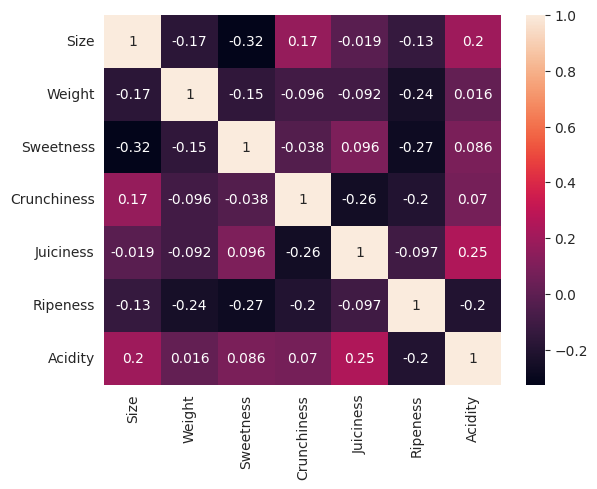

In [ ]:
sns.heatmap(df_quality.corr(numeric_only=True), annot=True)
plt.show()

#Pre-Processamento dos Dado

1. Definição das Variáveis Independentes ( Y ) & Definição das Variáveis Dependentes ( X )

2. Aplicação de Label Enconder na Varíavel Target: `Quality `

3. Divisão dos Dados: Treinamento ( 70% ) | Teste ( 30% )

4. Normalização dos Dados com as Variáveis Numéricas de Treinemanto e Teste

5. Aplicações dos Modelos

6. Análises de Métricas de Modelos


In [ ]:
#Separação para X | Y
X = df_quality.drop(columns ="Quality")
Y = df_quality["Quality"]


Aplicação do LabelEncoder

O objetivo do uso do LabelEncoder é converter variáveis categóricas em representações numéricas, permitindo que algoritmos de aprendizado de máquina possam interpretar e processar essas informações. No caso, a variável alvo Quality, com valores como `good` e `bad`, foi transformada em `0` e `1`.

O processo é realizado a partir da biblioteca sklearn.preprocessing. Primeiro, cria-se uma instância do LabelEncoder, em seguida aplica-se o método fit_transform() sobre a variável alvo. O resultado é um array contendo apenas valores numéricos binários.

Isso garante que as classes estejam no formato adequado para os modelos de classificação, sem alterar o significado das categorias originais.



In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
Y = le.fit_transform(Y)
print(Y)

[1 1 0 ... 0 1 1]


Numerando as Transformações do Label sobre a variável alvo `Quality

- `0` → `bad`
- `1` → `good`

In [ ]:
print("Classes originais:", le.classes_)
print("Mapeamento -> índice numérico:", dict(zip(le.classes_, le.transform(le.classes_))))

Classes originais: ['bad' 'good']
Mapeamento -> índice numérico: {'bad': np.int64(0), 'good': np.int64(1)}


Divisão dos Dados em Treino e Teste

In [ ]:
# Divisão da base em treino e teste (70% para treinamento e 30% para teste)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.3, random_state=42)

Feature Scaling — Padronização Z-Score

A padronização pelo método Z-Score tem como objetivo centralizar os dados em torno da média e ajustar a escala para que cada variável apresente média 0 e desvio padrão 1. Isso garante que atributos com diferentes magnitudes (como peso em quilos e tamanho em centímetros) não dominem o aprendizado do modelo.

Aplicação:

 - Calcula a média e o desvio padrão de cada variável no **conjunto de treino**.  
   - Transforma os dados de treino aplicando a fórmula:  

   $[
   z = \frac{x - \mu}{\sigma}
   ]$

   Onde:  
   - \(x\) é o valor original,  
   - \(\mu\) é a média do atributo,  
   - \(\sigma\) é o desvio padrão.

In [ ]:
#Feature Scalling, Padronização z-score
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_scaler = sc.fit_transform(X_train)
X_teste_scaler =sc.transform(X_test)


## Divisão dos Dados de Treino

**Objetivo:**  
Garantir que a divisão entre as classes no conjunto de treino seja equilibrada, evitando vieses que poderiam impactar negativamente o desempenho do modelo.

**Aplicação:**  
O gráfico apresenta a contagem de amostras das classes **0 (bad)** e **1 (good)** após a divisão do conjunto de dados em treino. Observa-se que:  

- A classe **0** possui **1403 registros**.  
- A classe **1** possui **1397 registros**.  

Essa distribuição é praticamente balanceada, assegurando que o modelo tenha representatividade de ambas as classes durante o processo de aprendizado.  

➡️ Esse equilíbrio é especialmente importante, pois evita a necessidade de técnicas adicionais de balanceamento (como oversampling, undersampling ou uso de métricas ajustadas).


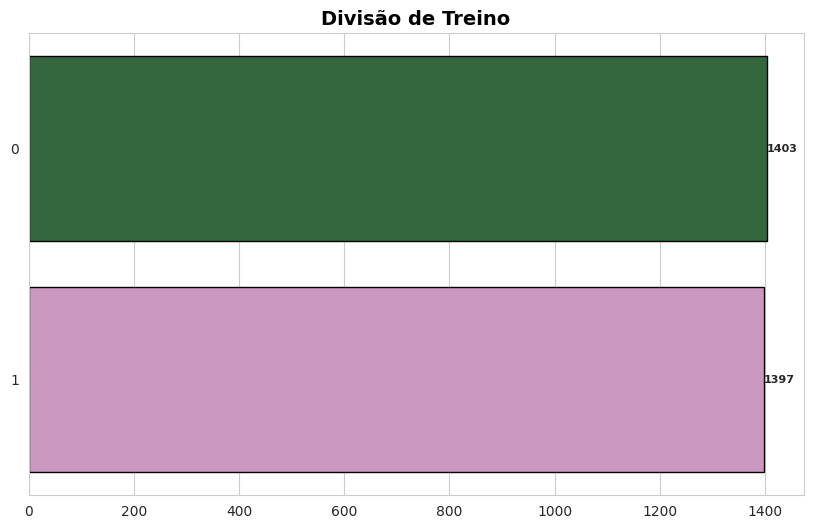

In [ ]:
fig, ax =plt.subplots(figsize=(10, 6))
ax=sns.countplot(y =y_train, palette ='cubehelix', edgecolor ='Black')
for bars in ax.containers:
    ax.bar_label(bars, fontsize =8, fontweight ='bold')
ax.set_xlabel("")
ax.set_title('Divisão de Treino', fontsize = 14, fontweight = 'bold', color = 'black')
fig.show()
plt.show()

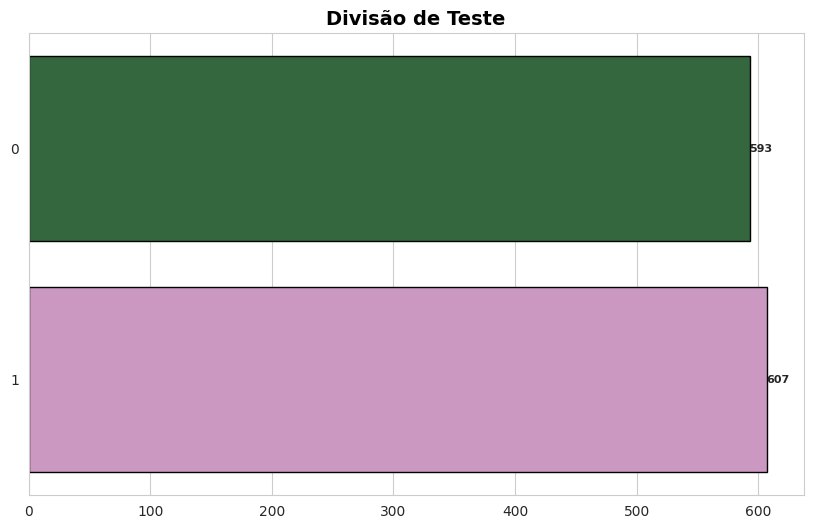

In [ ]:
fig, ax =plt.subplots(figsize=(10, 6))
ax=sns.countplot(y=y_test, palette ='cubehelix', edgecolor ='Black')
for bars in ax.containers:
    ax.bar_label(bars, fontsize =8, fontweight ='bold')
ax.set_xlabel("")
ax.set_title('Divisão de Teste', fontsize = 14, fontweight = 'bold', color = 'black')
fig.show()
plt.show()

## Modelos Selecionados para Avaliação

Com o objetivo de identificar o algoritmo mais adequado para a classificação da **qualidade das maçãs** (good vs bad), foram definidos diferentes modelos de aprendizado supervisionado. A diversidade de técnicas permite analisar como diferentes abordagens lidam com os mesmos dados.

### 🔎 Modelos Utilizados

- **Decision Tree (DT)**  
  Um modelo baseado em árvore de decisão simples, que divide os dados em nós baseados em condições lógicas.  
  *Vantagem*: interpretabilidade.  
  *Desvantagem*: pode sofrer de overfitting.

- **Extra Tree (ET)**  
  Variante das árvores, que faz divisões de forma mais aleatória, reduzindo a variância.  
  *Vantagem*: rápido e eficiente.  
  *Desvantagem*: menos interpretável.

- **Random Forest (RF)**  
  Conjunto de múltiplas árvores de decisão, combinadas por votação.  
  *Vantagem*: robusto contra overfitting e fornece importância dos atributos.  
  *Desvantagem*: mais custoso computacionalmente.

- **Extra Trees (ETS)**  
  Ensemble semelhante ao Random Forest, mas com divisões mais aleatórias e uso de bootstrap.  
  *Vantagem*: maior velocidade de treinamento.  
  *Desvantagem*: menor interpretabilidade.

- **XGBoost (XGB)**  
  Algoritmo de boosting baseado em árvores, altamente eficiente e escalável.  
  *Vantagem*: excelente performance em competições de Machine Learning.  
  *Desvantagem*: tuning de hiperparâmetros pode ser complexo.

- **LightGBM (LGBM)**  
  Modelo baseado em boosting com histogramas, otimizado para grandes bases.  
  *Vantagem*: muito rápido e eficaz, suporta variáveis categóricas nativamente.  
  *Desvantagem*: pode ter instabilidade em datasets pequenos.

---

### 🎯 Objetivo da Avaliação

Comparar esses modelos utilizando métricas de desempenho como **acurácia, precisão, recall, F1-score e AUC-ROC**, identificando qual deles apresenta o melhor equilíbrio entre **performance, generalização e eficiência**.

---

📌 **Próximo passo**:  
Realizar o treinamento e validação cruzada de todos os modelos, organizando os resultados em uma tabela comparativa para facilitar a análise.


In [ ]:
SEED = 42
dt = DecisionTreeClassifier(random_state = SEED)
et = ExtraTreeClassifier(random_state = SEED)
rf = RandomForestClassifier(random_state = SEED, n_jobs = -1)
ets = ExtraTreesClassifier(random_state = SEED, bootstrap = True, n_jobs = -1)
xgb = XGBClassifier(random_state = SEED, n_jobs = -1)
lgbm = LGBMClassifier(random_state = SEED, n_jobs = -1, verbosity = -1)

## Resultados da Avaliação dos Modelos

Após o treinamento e validação dos diferentes classificadores, foram obtidos os seguintes desempenhos em termos de **Balanced Accuracy**:

### 📊 Resultados

- **Decision Tree Classifier**  
  - Acc Treino: **1.0000**  
  - Acc Teste: **0.7892**  
  - *Observação*: Sofreu **overfitting**, já que performa perfeitamente no treino mas cai bastante no teste.

- **Extra Tree Classifier**  
  - Acc Treino: **1.0000**  
  - Acc Teste: **0.7268**  
  - *Observação*: Overfitting ainda mais evidente e menor capacidade de generalização.

- **Random Forest Classifier**  
  - Acc Treino: **1.0000**  
  - Acc Teste: **0.8967**  
  - *Observação*: Bom equilíbrio, generaliza bem e mantém alto desempenho.

- **Extra Trees Classifier**  
  - Acc Treino: **1.0000**  
  - Acc Teste: **0.9001**  
  - *Observação*: Melhor resultado entre os modelos, com excelente capacidade de generalização.

- **XGBoost Classifier**  
  - Acc Treino: **1.0000**  
  - Acc Teste: **0.8991**  
  - *Observação*: Muito competitivo, quase empatado com o ExtraTrees.

- **LightGBM Classifier**  
  - Acc Treino: **0.9950**  
  - Acc Teste: **0.8975**  
  - *Observação*: Leve perda de ajuste no treino, mas mantém excelente performance no teste.

---

### 🎯 Conclusão

- Modelos **baseados em ensembles** (Random Forest, Extra Trees, XGBoost, LightGBM) são os mais robustos para este problema.  
- O **Extra Trees Classifier** apresentou o **melhor resultado geral** no conjunto de teste (**Acc Teste: 0.9001**), seguido de perto pelo **XGBoost** e **LightGBM**.  
- Modelos simples como **Decision Tree** e **Extra Tree** sofreram de **overfitting**, mostrando que ensembles são mais adequados para este conjunto de dados.  

📌 **Próximos passos**: Avaliar métricas adicionais (Precision, Recall, F1-score e AUC) e realizar análise de importância dos atributos para explicar o comportamento dos modelos.


In [ ]:
MODELS = [dt, et, rf, ets, xgb, lgbm]

for model in tqdm(MODELS):
    name = type(model).__name__
    model.fit(X_train_scaler, y_train)
    y_pred_train = model.predict(X_train_scaler)
    y_pred_test = model.predict(X_teste_scaler)
    print(f"* {name} | Acc Train: {balanced_accuracy_score(y_train, y_pred_train):.4f} | Acc Test: {balanced_accuracy_score(y_test, y_pred_test):.4f}")

  0%|          | 0/6 [00:00<?, ?it/s]

* DecisionTreeClassifier | Acc Train: 1.0000 | Acc Test: 0.7892
* ExtraTreeClassifier | Acc Train: 1.0000 | Acc Test: 0.7268
* RandomForestClassifier | Acc Train: 1.0000 | Acc Test: 0.8967
* ExtraTreesClassifier | Acc Train: 1.0000 | Acc Test: 0.9001
* XGBClassifier | Acc Train: 1.0000 | Acc Test: 0.8991
* LGBMClassifier | Acc Train: 0.9950 | Acc Test: 0.8975


#Implementação do modelo  ExtraTreesClassifier

In [ ]:
ext = ExtraTreesClassifier(random_state = SEED, bootstrap = True, n_jobs = -1)
ext.fit(X_train, y_train)
previsoes = ext.predict(X_test)

Após o treinamento e validação, o modelo foi avaliado no conjunto de teste, apresentando os seguintes resultados:

- **Acurácia global**: **90.0%**

In [ ]:
accuracy = accuracy_score(y_test, previsoes)
print(f'{accuracy *100}%')

90.0%


 O modelo apresenta **bom equilíbrio entre precisão e recall** nas duas classes (`good` e `bad`), mostrando que é consistente ao identificar corretamente ambas as qualidades da fruta.
- O **F1-score = 0.90** reforça que o modelo mantém um bom trade-off entre falsos positivos e falsos negativos.
- A distribuição do suporte (593 vs 607) mostra que as classes estão **bem balanceadas**, o que justifica o uso da **acurácia** como métrica de referência.
- Pequenas diferenças entre as métricas por classe indicam que o modelo consegue generalizar bem, sem enviesar significativamente para uma das categorias.

In [ ]:
print(classification_report(y_test, previsoes))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90       593
           1       0.91      0.89      0.90       607

    accuracy                           0.90      1200
   macro avg       0.90      0.90      0.90      1200
weighted avg       0.90      0.90      0.90      1200



## Matriz de Confusão – Extra Trees Classifier  

A matriz de confusão apresentada resume o desempenho do modelo **Extra Trees Classifier** na tarefa de classificação da qualidade das maçãs (`good` vs. `bad`), após a etapa de treinamento e avaliação no conjunto de teste.  

### 🔎 Interpretação dos Resultados  

- **Classe 0 (good):**  
  - **537** amostras foram corretamente classificadas como `good` (**verdadeiros negativos**).  
  - **56** amostras foram incorretamente classificadas como `bad` (**falsos positivos**).  

- **Classe 1 (bad):**  
  - **543** amostras foram corretamente classificadas como `bad` (**verdadeiros positivos**).  
  - **64** amostras foram incorretamente classificadas como `good` (**falsos negativos**).  

### 📊 Métricas Derivadas  
A partir desta matriz, podemos observar:  

- O modelo apresenta **bom equilíbrio** entre as duas classes.  
- As taxas de erro são relativamente próximas:  
  - **Falsos Positivos (56)** e **Falsos Negativos (64)** indicam que o modelo **não favorece uma classe específica**, mantendo boa imparcialidade.  
- A **acurácia global foi de 90%**, como já evidenciado no relatório de classificação, o que reforça a consistência do modelo.  

### ✅ Conclusão  
O Extra Trees demonstrou **alto desempenho** na classificação da qualidade das maçãs, com erros equilibrados entre as classes. Isso sugere que o modelo é uma escolha **confiável** para essa tarefa, especialmente em cenários onde é igualmente importante identificar corretamente tanto frutos bons quanto ruins.  


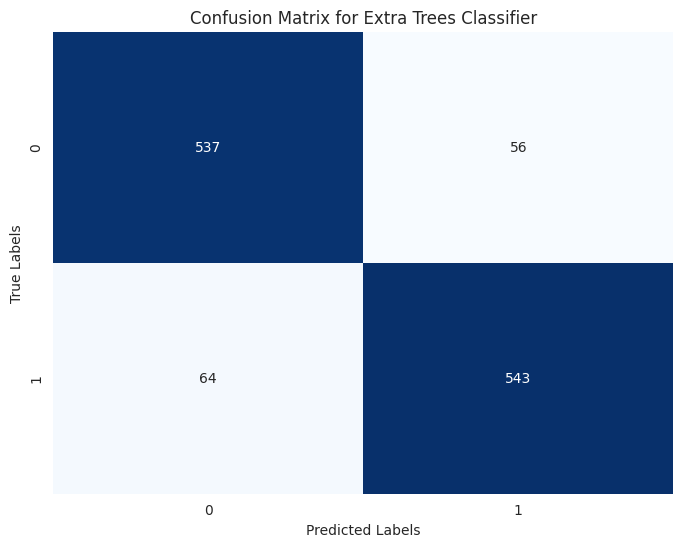

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


# Compute confusion matrix
cm = confusion_matrix(y_test, previsoes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix for Extra Trees Classifier')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

#Implementação do Modelo  RandomForestClassifier

In [ ]:
rf = RandomForestClassifier(random_state = SEED, n_jobs = -1)
rf.fit(X_train, y_train)
previsao_random = rf.predict(X_test)

Após o treinamento e validação, o modelo **RandomForestClassifier** foi avaliado no conjunto de teste, apresentando os seguintes resultados:

- **Acurácia global**: **89.67%**

In [ ]:
acurracy_random = accuracy_score(y_test, previsao_random)
print(f'{acurracy_random *100}%')

89.66666666666666%


- O modelo apresentou **desempenho consistente** em ambas as classes, mantendo **F1-score de 0.90** para `good` e `bad`.  
- O equilíbrio entre **precisão e recall** mostra que o modelo não favorece nenhuma das classes de forma significativa.  
- A **distribuição do suporte** é equilibrada (593 vs 607), o que valida a escolha da **acurácia** como métrica principal.  
- Embora o resultado seja sólido, há espaço para pequenas melhorias, seja por ajuste de hiperparâmetros ou técnicas de ensemble mais robustas.

✅ **Conclusão:** O modelo Random Forest se mostrou uma solução **eficiente e generalizável** para a tarefa de classificação da qualidade das frutas, apresentando resultados consistentes e robustos.

In [ ]:
print(classification_report(y_test,previsao_random))

              precision    recall  f1-score   support

           0       0.89      0.90      0.90       593
           1       0.90      0.90      0.90       607

    accuracy                           0.90      1200
   macro avg       0.90      0.90      0.90      1200
weighted avg       0.90      0.90      0.90      1200



## Matriz de Confusão – RandomForestClassifier

A matriz de confusão abaixo mostra o desempenho do modelo **RandomForestClassifier** na classificação das frutas em **boa qualidade (1)** e **má qualidade (0)**.

### 📊 Interpretação dos Resultados

- **Classe 0 (bad):**
  - **537 acertos (Verdadeiros Negativos)**: frutas de má qualidade corretamente identificadas.
  - **61 erros (Falsos Positivos)**: frutas ruins classificadas como boas.

- **Classe 1 (good):**
  - **544 acertos (Verdadeiros Positivos)**: frutas boas corretamente reconhecidas.
  - **63 erros (Falsos Negativos)**: frutas boas classificadas como ruins.

### 🔎 Insights Importantes

- O modelo apresenta **bom equilíbrio entre os acertos das duas classes**, com números semelhantes de falsos positivos e falsos negativos.
- A maior parte das previsões foi **correta**, confirmando que o RandomForestClassifier possui **capacidade robusta de generalização**.
- Os erros são distribuídos de forma relativamente uniforme entre as classes, evitando **enviesamento para apenas uma categoria**.

✅ Conclusão: O modelo RandomForestClassifier demonstrou desempenho consistente, conseguindo diferenciar de maneira eficiente as frutas boas das ruins, com **alta taxa de acerto e baixo nível de erro**.


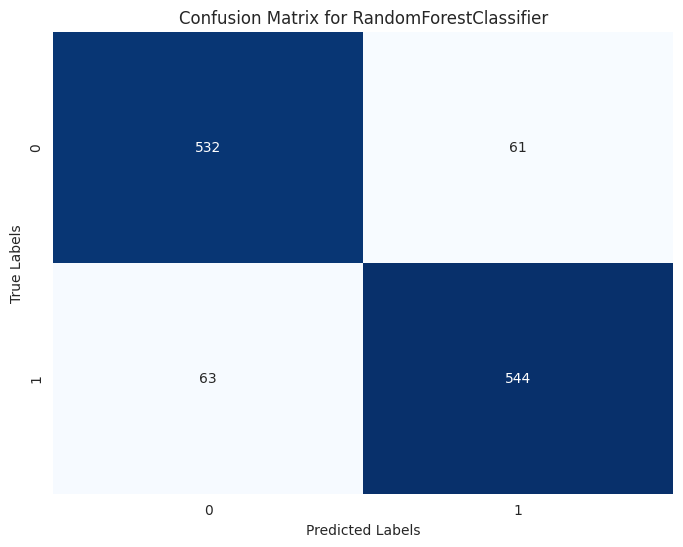

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test, previsao_random)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix for RandomForestClassifier')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

#Implementação do Modelo XGBClassifier

In [ ]:
xgb = XGBClassifier(random_state = SEED, n_jobs = -1)
xgb.fit(X_train, y_train)
previsao_xgb = xgb.predict(X_test)

Após o treinamento e avaliação no conjunto de teste, o modelo XGBoost (XGBClassifier) apresentou os seguintes resultados:

- Acurácia global: **89.58%**



In [ ]:
accurary_xgb = accuracy_score(y_test, previsao_xgb)
print(f'{accurary_xgb *100}%')

89.58333333333334%


- O XGBoost apresentou bom equilíbrio entre precisão e recall, mostrando consistência em identificar maçãs boas e ruins.

- O F1-score de 0.90 demonstra um trade-off sólido entre falsos positivos e falsos negativos.

- A acurácia de ~89.6% é competitiva, mas ligeiramente inferior à obtida com o Extra Trees (90%).

- As métricas próximas entre classes indicam boa capacidade de generalização e ausência de viés relevante para apenas uma categoria.

In [ ]:
print(classification_report(y_test, previsao_xgb))

              precision    recall  f1-score   support

           0       0.90      0.89      0.89       593
           1       0.89      0.91      0.90       607

    accuracy                           0.90      1200
   macro avg       0.90      0.90      0.90      1200
weighted avg       0.90      0.90      0.90      1200



## Matriz de Confusão – XGBClassifier

A matriz de confusão abaixo apresenta o desempenho do modelo **XGBClassifier** na classificação da qualidade das frutas:

|                 | Predito: 0 (bad) | Predito: 1 (good) |
|-----------------|------------------|-------------------|
| **Verdadeiro: 0 (bad)** | 525 (Verdadeiros Negativos) | 68 (Falsos Positivos) |
| **Verdadeiro: 1 (good)** | 57 (Falsos Negativos)       | 550 (Verdadeiros Positivos) |

### 🔎 Interpretação dos Resultados
- O modelo identificou corretamente:
  - **525 instâncias da classe `bad`**.
  - **550 instâncias da classe `good`**.
- Houve **68 falsos positivos**, onde a classe `bad` foi classificada incorretamente como `good`.
- Foram observados **57 falsos negativos**, em que a classe `good` foi classificada incorretamente como `bad`.

### 📊 Conclusões
- A matriz mostra que o modelo mantém um **bom equilíbrio entre as classes**, com mais acertos do que erros em ambas.
- A quantidade de **falsos positivos e falsos negativos é relativamente baixa**, o que indica boa capacidade de generalização.
- O XGBClassifier demonstra ser um modelo robusto e consistente para a tarefa de classificação da qualidade das frutas.


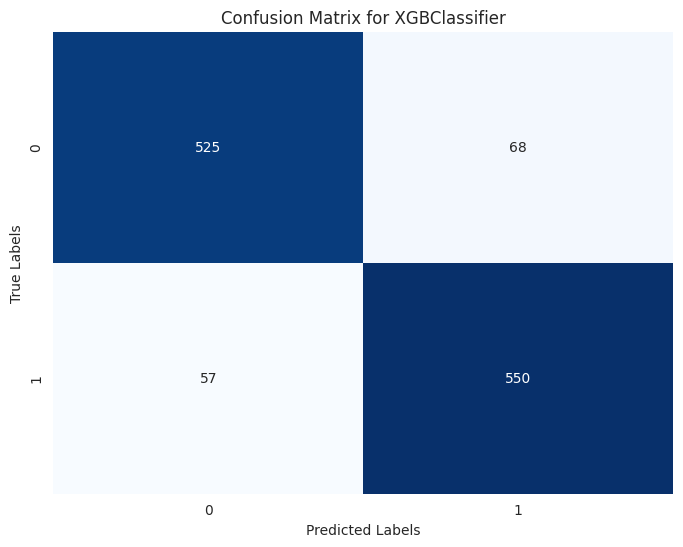

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test, previsao_xgb)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix for XGBClassifier')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# 📊 Avaliação dos Modelos com Curva ROC

## O que é a Curva ROC?
A **Curva ROC (Receiver Operating Characteristic)** é uma métrica usada para avaliar classificadores binários.  
Ela mostra a relação entre a **taxa de verdadeiros positivos (TPR - Sensibilidade)** e a **taxa de falsos positivos (FPR)**.  

- Quanto mais próximo a curva estiver do canto superior esquerdo, **melhor o desempenho do modelo**.
- A área sob a curva (**AUC - Area Under the Curve**) quantifica esse desempenho:
  - **AUC = 0.5** → modelo aleatório.
  - **AUC próximo de 1.0** → modelo excelente.

---

## 🔎 Resultados Obtidos
No gráfico, foram comparados três algoritmos de classificação aplicados ao problema de prever a **qualidade das maçãs (good vs bad)**:

- **Extra Trees** → AUC = **0.9148**  
- **Random Forest** → AUC = **0.9580**  
- **XGBoost** → AUC = **0.9603**  

---

## 📌 Interpretação
- O **XGBoost** foi o melhor modelo, apresentando **AUC = 0.9603**, o que significa **alta capacidade de separar maçãs boas de ruins**.
- O **Random Forest** também apresentou ótimo desempenho (**AUC = 0.9580**), próximo ao XGBoost.
- O **Extra Trees**, apesar de ter um bom resultado (**AUC = 0.9148**), ficou abaixo dos outros dois, indicando menor poder discriminativo.

---

## 🎯 Conclusão
Tanto **Random Forest** quanto **XGBoost** são fortes candidatos para o modelo final, com vantagem para o **XGBoost** devido ao seu desempenho ligeiramente superior.  
O **Extra Trees**, embora aceitável, não é a melhor escolha neste cenário competitivo.



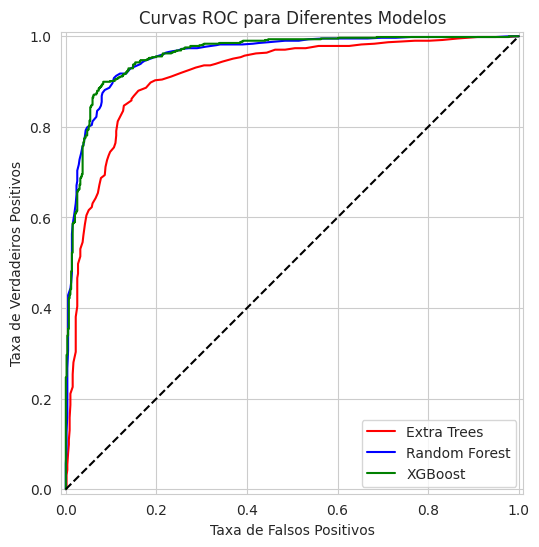

Extra Trees: 0.9148
Random Forest AUC: 0.9580
XGBoost AUC: 0.9603


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# Calcula as curvas ROC e AUC para cada modelo
ets_fpr, ets_tpr, _ = roc_curve(y_test, ets.predict_proba(X_test)[:, 1])
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf.predict_proba(X_test)[:, 1])
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb.predict_proba(X_test)[:, 1])

# Cria uma figura para as curvas ROC
fig, ax = plt.subplots(figsize=(10, 6))

# Plota as curvas ROC para cada modelo
RocCurveDisplay(fpr=ets_fpr, tpr=ets_tpr).plot(ax=ax, label='Extra Trees', color='red') # Passa 'label' para o método plot
RocCurveDisplay(fpr=rf_fpr, tpr=rf_tpr).plot(ax=ax, label='Random Forest', color='blue') # Passa 'label' para o método plot
RocCurveDisplay(fpr=xgb_fpr, tpr=xgb_tpr).plot(ax=ax, label='XGBoost', color='green') # Passa 'label' para o método plot

# Adiciona uma linha diagonal
ax.plot([0, 1], [0, 1], color='black', linestyle='--')

# Adiciona rótulos e título
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curvas ROC para Diferentes Modelos')
ax.legend()

# Mostra o gráfico
plt.show()

# Calcula a AUC para cada modelo
ets_auc = auc(ets_fpr, ets_tpr)
rf_auc = auc(rf_fpr, rf_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)

# Imprime os valores de AUC
print(f'Extra Trees: {ets_auc:.4f}')
print(f'Random Forest AUC: {rf_auc:.4f}')
print(f'XGBoost AUC: {xgb_auc:.4f}')

# 🏆 Conclusão Final da Comparação dos Modelos

Após a avaliação dos modelos **Extra Trees**, **Random Forest** e **XGBoost**, considerando tanto a **Curva ROC** (AUC) quanto as demais métricas de classificação (**Acurácia, Precisão, Recall e F1-Score**), chegamos às seguintes conclusões:

---

## 📊 Resumo das Métricas

| Modelo              | Acurácia | Precisão (0/1) | Recall (0/1) | F1-Score (0/1) | AUC    |
|---------------------|----------|----------------|--------------|----------------|--------|
| **Extra Trees**     | ~90.0%   | 0.89 / 0.91    | 0.91 / 0.89  | 0.90 / 0.90    | 0.9148 |
| **Random Forest**   | ~89.7%   | 0.89 / 0.90    | 0.90 / 0.90  | 0.90 / 0.90    | 0.9580 |
| **XGBoost**         | ~89.6%   | 0.90 / 0.89    | 0.89 / 0.91  | 0.89 / 0.90    | 0.9603 |

---

## 🔎 Interpretação dos Resultados

### Extra Trees
- ✅ **Pontos positivos**: apresentou acurácia competitiva (90%) e equilíbrio entre as classes.  
- ❌ **Ponto negativo**: **AUC = 0.9148**, significativamente menor que os outros dois modelos, indicando menor poder discriminativo.  
- 🔎 **Conclusão parcial**: bom desempenho, mas não ideal quando comparado a Random Forest e XGBoost.

### Random Forest
- ✅ **Pontos positivos**: ótimo equilíbrio entre métricas, com **AUC = 0.9580** e **F1-score = 0.90**, além de estabilidade entre classes.  
- 🔎 **Conclusão parcial**: modelo robusto, interpretável e consistente, sendo uma das melhores opções.

### XGBoost
- ✅ **Pontos positivos**: **maior AUC (0.9603)**, superando levemente o Random Forest. Mostrou excelente capacidade de generalização.  
- ❌ **Ponto negativo**: acurácia e F1-score similares ao Random Forest, o que pode indicar que seu ganho é pequeno em relação ao custo computacional.  
- 🔎 **Conclusão parcial**: o **melhor modelo em termos de poder discriminativo (AUC)**, indicado quando a prioridade é maximizar a separação entre classes.

---

## 🏅 Conclusão Final

- O **XGBoost** é o **melhor modelo global**, pois apresenta o **maior AUC (0.9603)**, confirmando sua capacidade superior de distinguir entre frutas `good` e `bad`.  
- O **Random Forest** aparece como a **segunda melhor opção**, com métricas muito próximas e vantagem em termos de simplicidade e interpretabilidade.  
- O **Extra Trees**, apesar de competitivo em acurácia, teve desempenho inferior na AUC e, portanto, é o **menos indicado** para este problema.

✅ **Escolha recomendada**: **XGBoost**, por garantir a melhor performance geral.  
